## README — How to Reproduce

**Step 1:** Open this notebook in Google Colab
**Step 2:** Enable GPU — Runtime → Change runtime type → **T4 GPU**
**Step 3:** Get a free Roboflow API key:
- Go to https://roboflow.com → Sign up (free)
- Go to Settings → API Keys → copy your key
- Paste it in Section 2 where it says `ROBOFLOW_API_KEY = "YOUR_KEY_HERE"`

**Step 4:** Runtime → Run all
**Expected runtime:** ~25–40 minutes on T4 GPU


## Section 1: Install Dependencies

In [1]:
# Install the required libraries for this project.
# We're using specific versions of torch and torchvision to make sure everything works smoothly together.
# ultralytics is needed for running YOLO models, and roboflow helps with handling datasets.
# The --upgrade flag makes sure we get the latest versions (or update them if already installed).

!pip install torch==2.5.1 torchvision==0.20.1 ultralytics roboflow --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 801.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 122.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# Import the PyTorch library so we can check system and GPU details
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# If a GPU is available, show its details
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    # Show a warning if no GPU is detected
    print("WARNING: No GPU detected. Go to Runtime → Change runtime type → T4 GPU")

PyTorch: 2.5.1+cu124
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## Section 2: Configuration — ADD YOUR ROBOFLOW KEY HERE

In [3]:
# Import standard libraries for file handling, randomness, timing, and compression
import os, random, time, shutil, glob, zipfile

# Path handling made easier and more readable
from pathlib import Path

# Numerical and data processing libraries
import numpy as np
import pandas as pd

# Libraries for plotting and visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# Image handling
from PIL import Image

# YOLO model from Ultralytics for object detection
from ultralytics import YOLO

# Counter helps count occurrences (e.g., class frequencies)
from collections import Counter


# ── PASTE YOUR ROBOFLOW API KEY BELOW ──────────────────────────────
# This key is used to access and download datasets from Roboflow
ROBOFLOW_API_KEY = "Your_key_here"   # <-- replace this before running


# Training configuration settings
EPOCHS     = 50     # Number of training iterations over the dataset
IMG_SIZE   = 640    # Image resolution used for training
BATCH_SIZE = 16     # Number of images processed at once
DEVICE     = 0 if torch.cuda.is_available() else 'cpu'  # Use GPU if available, otherwise CPU
SEED       = 42     # Seed for reproducibility (same random results each run)
CONF_THRES = 0.25  # Confidence threshold for predictions
IOU_THRES  = 0.45  # IoU threshold for filtering overlapping boxes


# Set seeds so results are consistent across runs
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# Define colours for each class when visualising bounding boxes
CLASS_COLORS = {
    'batsman':       '#2196F3',
    'bowler':        '#FF5722',
    'umpire':        '#9C27B0',
    'wicket keeper': '#4CAF50',
    'wicketkeeper':  '#4CAF50',
    'ball':          '#FFD700',
    'stumps':        '#FF9800',
    'nonstriker':    '#00BCD4',
    'default':       '#E91E63'
}

print("Config loaded.")
print(f"Epochs: {EPOCHS} | Image size: {IMG_SIZE} | Batch: {BATCH_SIZE} | Device: {DEVICE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Config loaded.
Epochs: 50 | Image size: 640 | Batch: 16 | Device: 0


## Section 3: Dataset Download

In [4]:
# Import Roboflow to access and download datasets
from roboflow import Roboflow

# Initialize Roboflow using your API key
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Dataset 1
print("Downloading Dataset 1...")

# Access the first dataset from the specified workspace and project
project1 = rf.workspace("cricket-jjknd").project("cricket-oftm6")

# Download version 1 of the dataset in YOLOv8 format and save it locally
dataset1 = project1.version(1).download("yolov8", location="datasets/cricket_scene")

# Show where the dataset is stored
print(f"Dataset 1 saved to: {dataset1.location}")


# Dataset 2
print("\nDownloading Dataset 2...")

# Access the second dataset from a different workspace and project
project2 = rf.workspace("neel-ckwq4").project("cricket-players-mugu4")

# Download version 1 of the dataset in YOLOv8 format and save it locally
dataset2 = project2.version(1).download("yolov8", location="datasets/cricket_players")

# Show where the dataset is stored
print(f"Dataset 2 saved to: {dataset2.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to datasets/cricket_scene in yolov8:: 100%|██████████| 620/620 [00:00<00:00, 9109.75it/s]

Dataset 1 saved to: /content/datasets/cricket_scene

loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to datasets/cricket_players in yolov8:: 100%|██████████| 5220/5220 [00:00<00:00, 7450.58it/s]

Dataset 2 saved to: /content/datasets/cricket_players


In [5]:
# Merge both datasets into one unified dataset
# Import YAML for reading configs and shutil for copying files
import yaml, shutil

# Define the directory where the merged dataset will be stored
MERGED_DIR = Path('datasets/cricket_merged')

# Create folder structure for train, validation, and test splits
for split in ['train', 'valid', 'test']:
    (MERGED_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (MERGED_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)


# Function to copy images and labels from a source dataset into the merged dataset
def copy_split(src_root, split, prefix):
    src_root = Path(src_root)
    img_src = src_root / split / 'images'
    lbl_src = src_root / split / 'labels'

    # Skip if the split does not exist in the source dataset
    if not img_src.exists():
        print(f"  Skipping {split} (not found in {src_root.name})")
        return 0

    count = 0

    # Loop through all image files in the split
    for img in img_src.glob('*.*'):
        # Copy image with a prefix to avoid filename conflicts
        dst_img = MERGED_DIR / split / 'images' / f"{prefix}_{img.name}"
        shutil.copy2(img, dst_img)

        # Copy corresponding label file if it exists
        lbl = lbl_src / (img.stem + '.txt')
        if lbl.exists():
            shutil.copy2(lbl, MERGED_DIR / split / 'labels' / f"{prefix}_{lbl.name}")

        count += 1

    return count


# Get dataset locations
d1 = dataset1.location
d2 = dataset2.location

# Copy data from both datasets into the merged structure
for split in ['train', 'valid', 'test']:
    n1 = copy_split(d1, split, 'ds1')
    n2 = copy_split(d2, split, 'ds2')
    print(f"{split}: {n1} from dataset1 + {n2} from dataset2 = {n1+n2} total")


# Function to load YAML configuration from a dataset
def load_yaml(path):
    # Look for data.yaml or any yaml file in the dataset directory
    candidates = list(Path(path).rglob('data.yaml')) + list(Path(path).glob('*.yaml'))

    for c in candidates:
        with open(c) as f:
            return yaml.safe_load(f)

    return {}


# Load configuration files from both datasets
cfg1 = load_yaml(d1)
cfg2 = load_yaml(d2)

# Extract class names
names1 = cfg1.get('names', [])
names2 = cfg2.get('names', [])

# Convert dictionary format to list if needed
if isinstance(names1, dict): names1 = list(names1.values())
if isinstance(names2, dict): names2 = list(names2.values())

print(f"\nDataset 1 classes: {names1}")
print(f"Dataset 2 classes: {names2}")


# Define a unified class list (standardised naming across datasets)
unified_classes = ['batsman', 'bowler', 'umpire', 'wicket keeper', 'ball', 'stumps']


# Create a new data.yaml file for the merged dataset
merged_yaml = {
    'path': str(MERGED_DIR.absolute()),  # Root path of dataset
    'train': 'train/images',             # Training images path
    'val':   'valid/images',             # Validation images path
    'test':  'test/images',              # Test images path
    'nc':    len(unified_classes),       # Number of classes
    'names': unified_classes             # Class names
}

# Save the merged YAML file
yaml_path = MERGED_DIR / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(merged_yaml, f, default_flow_style=False)

print(f"\nMerged dataset YAML written: {yaml_path}")
print(f"Unified classes ({len(unified_classes)}): {unified_classes}")

train: 241 from dataset1 + 1823 from dataset2 = 2064 total
valid: 32 from dataset1 + 521 from dataset2 = 553 total
test: 31 from dataset1 + 260 from dataset2 = 291 total

Dataset 1 classes: ['-1', 'ball', 'batsman', 'bowler', 'nonstriker', 'umpire', 'wicketkeeper']
Dataset 2 classes: ['Batsman', 'Bowler', 'Umpire', 'Wicket Keeper', 'players']

Merged dataset YAML written: datasets/cricket_merged/data.yaml
Unified classes (6): ['batsman', 'bowler', 'umpire', 'wicket keeper', 'ball', 'stumps']


In [6]:
# Remap label class IDs to match unified_classes

# Function to create a mapping from old class IDs to new unified class IDs
def build_remap(old_names, new_names):
    remap = {}

    # Normalize class names (lowercase + remove extra spaces)
    old_names_norm = [n.lower().strip() for n in old_names]
    new_names_norm = [n.lower().strip() for n in new_names]

    # Loop through old class names and find corresponding new class index
    for old_id, old_name in enumerate(old_names_norm):
        # Try exact match first
        if old_name in new_names_norm:
            remap[old_id] = new_names_norm.index(old_name)
        else:
            # Try partial match (handles small naming differences)
            for new_id, new_name in enumerate(new_names_norm):
                if old_name.replace(' ','') == new_name.replace(' ','') or \
                   old_name in new_name or new_name in old_name:
                    remap[old_id] = new_id
                    break

    return remap


# Build remapping dictionaries for both datasets
remap1 = build_remap(names1, unified_classes)
remap2 = build_remap(names2, unified_classes)

print(f"Remap dataset1: {remap1}")
print(f"Remap dataset2: {remap2}")


# Function to update label files with new class IDs
def remap_labels(label_dir, prefix, remap):
    label_dir = Path(label_dir)
    fixed = skipped = 0

    # Loop through label files belonging to a specific dataset (using prefix)
    for lbl in label_dir.glob(f'{prefix}_*.txt'):
        lines = lbl.read_text().strip().split('\n')
        new_lines = []

        # Process each annotation line
        for line in lines:
            if not line.strip():
                continue

            parts = line.split()
            old_id = int(parts[0])

            # Replace old class ID with new one if mapping exists
            if old_id in remap:
                parts[0] = str(remap[old_id])
                new_lines.append(' '.join(parts))
            else:
                skipped += 1  # Count annotations that couldn't be mapped

        # Overwrite file with updated labels
        lbl.write_text('\n'.join(new_lines))
        fixed += 1

    return fixed, skipped


# Apply remapping to all dataset splits
for split in ['train', 'valid', 'test']:
    ldir = MERGED_DIR / split / 'labels'

    # Remap labels from both datasets separately using their prefixes
    f1, s1 = remap_labels(ldir, 'ds1', remap1)
    f2, s2 = remap_labels(ldir, 'ds2', remap2)

    print(f"{split}: remapped {f1+f2} files, skipped {s1+s2} annotations")


print("\nLabel remapping complete. Dataset ready for training.")

Remap dataset1: {1: 4, 2: 0, 3: 1, 5: 2, 6: 3}
Remap dataset2: {0: 0, 1: 1, 2: 2, 3: 3}
train: remapped 2064 files, skipped 558 annotations
valid: remapped 553 files, skipped 136 annotations
test: remapped 291 files, skipped 76 annotations

Label remapping complete. Dataset ready for training.


## Section 4: Exploratory Data Analysis (EDA)

In [7]:
# Count class distribution across train split

# Store class names and total number of classes
CLASS_NAMES = unified_classes
NC = len(CLASS_NAMES)


# Function to analyse a dataset split (train/valid/test)
def analyse_split(split):
    lbl_dir = MERGED_DIR / split / 'labels'

    # Initialize counters and storage lists
    class_counts = Counter()
    bbox_per_img = []
    img_sizes = []
    wh_ratios = []

    # Loop through all label files
    for lbl in lbl_dir.glob('*.txt'):
        # Read valid (non-empty) annotation lines
        lines = [l for l in lbl.read_text().strip().split('\n') if l.strip()]

        # Count number of bounding boxes in this image
        bbox_per_img.append(len(lines))

        # Process each annotation
        for line in lines:
            parts = line.split()
            if len(parts) < 5:
                continue

            cls_id = int(parts[0])

            # Count class occurrences
            if cls_id < NC:
                class_counts[CLASS_NAMES[cls_id]] += 1

            # Extract width and height to compute aspect ratio
            w, h = float(parts[3]), float(parts[4])
            wh_ratios.append(w / (h + 1e-9))


    # Sample some images to get size information (limit to 50 for speed)
    img_dir = MERGED_DIR / split / 'images'
    for img_path in list(img_dir.glob('*.*'))[:50]:
        try:
            im = Image.open(img_path)
            img_sizes.append(im.size)
        except:
            pass

    return class_counts, bbox_per_img, img_sizes, wh_ratios


# Analyse train and validation splits
train_counts, train_bboxes, train_sizes, train_wh = analyse_split('train')
val_counts,   val_bboxes,   val_sizes,   val_wh   = analyse_split('valid')


# Calculate total number of images in train + validation
total_imgs = len(list((MERGED_DIR / 'train' / 'images').glob('*.*'))) + \
             len(list((MERGED_DIR / 'valid' / 'images').glob('*.*')))


print("Dataset statistics:")
print(f"  Total images (train+val): {total_imgs}")

print(f"  Train class distribution:")
for cls, cnt in sorted(train_counts.items()):
    print(f"    {cls:20s}: {cnt}")

# Average number of bounding boxes per image
print(f"  Avg bboxes per image: {np.mean(train_bboxes):.1f}")

# Maximum number of bounding boxes in a single image
print(f"  Max bboxes in one image: {max(train_bboxes) if train_bboxes else 0}")

Dataset statistics:
  Total images (train+val): 2617
  Train class distribution:
    ball                : 72
    batsman             : 1887
    bowler              : 972
    umpire              : 667
    wicket keeper       : 609
  Avg bboxes per image: 2.0
  Max bboxes in one image: 6


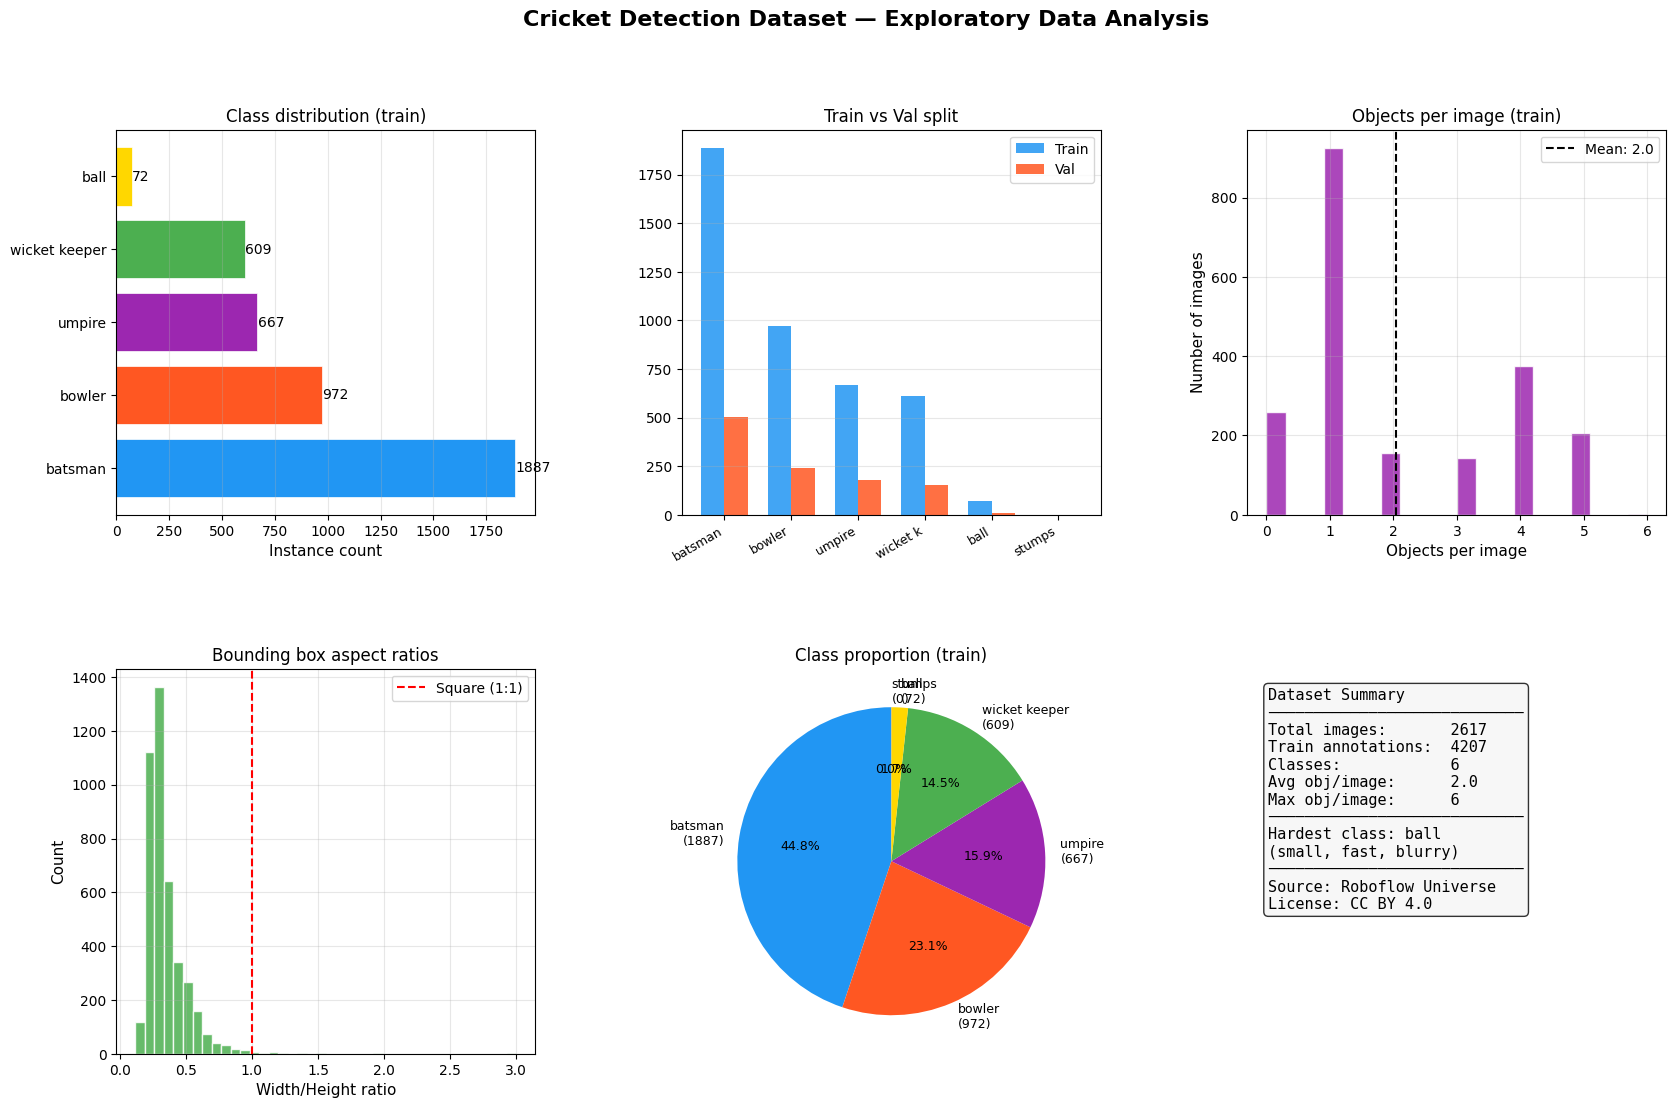

Saved: eda_cricket.png


In [8]:
# EDA plots

# Create a large figure for multiple subplots
fig = plt.figure(figsize=(20, 12))

# Add a main title to the figure
fig.suptitle('Cricket Detection Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Define grid layout (2 rows x 3 columns)
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Assign colors to each class (fallback to grey if not defined)
COLOR_MAP = [CLASS_COLORS.get(c, '#888') for c in CLASS_NAMES]


# 1. Class distribution bar chart
ax1 = fig.add_subplot(gs[0, 0])

# Sort classes by frequency (highest first)
classes_sorted = sorted(train_counts.keys(), key=lambda x: train_counts[x], reverse=True)
counts_sorted  = [train_counts[c] for c in classes_sorted]
colors_sorted  = [CLASS_COLORS.get(c, '#888') for c in classes_sorted]

# Create horizontal bar chart
bars = ax1.barh(classes_sorted, counts_sorted, color=colors_sorted, edgecolor='white', linewidth=0.5)

ax1.set_xlabel('Instance count', fontsize=11)
ax1.set_title('Class distribution (train)', fontsize=12)
ax1.grid(axis='x', alpha=0.3)

# Add count labels next to bars
for bar, cnt in zip(bars, counts_sorted):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             str(cnt), va='center', fontsize=10)


# 2. Train vs Val class comparison
ax2 = fig.add_subplot(gs[0, 1])

# X positions for bars
x = np.arange(len(CLASS_NAMES))
w = 0.35

# Plot train and validation distributions side by side
ax2.bar(x - w/2, [train_counts.get(c, 0) for c in CLASS_NAMES], w,
        label='Train', color='#2196F3', alpha=0.85)

ax2.bar(x + w/2, [val_counts.get(c, 0) for c in CLASS_NAMES], w,
        label='Val', color='#FF5722', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels([c[:8] for c in CLASS_NAMES], rotation=30, ha='right', fontsize=9)
ax2.set_title('Train vs Val split', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)


# 3. Bboxes per image histogram
ax3 = fig.add_subplot(gs[0, 2])

# Plot histogram of number of objects per image
ax3.hist(train_bboxes, bins=20, color='#9C27B0', edgecolor='white', alpha=0.85)

# Add vertical line for mean value
ax3.axvline(np.mean(train_bboxes), color='black', linestyle='--', linewidth=1.5,
            label=f'Mean: {np.mean(train_bboxes):.1f}')

ax3.set_xlabel('Objects per image', fontsize=11)
ax3.set_ylabel('Number of images', fontsize=11)
ax3.set_title('Objects per image (train)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)


# 4. Bbox aspect ratio distribution
ax4 = fig.add_subplot(gs[1, 0])

# Clip extreme ratios for better visualization and plot histogram
ax4.hist(np.clip(train_wh, 0, 5), bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)

ax4.set_xlabel('Width/Height ratio', fontsize=11)
ax4.set_ylabel('Count', fontsize=11)
ax4.set_title('Bounding box aspect ratios', fontsize=12)

# Add reference line for square boxes (ratio = 1)
ax4.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Square (1:1)')
ax4.legend(fontsize=10)
ax4.grid(alpha=0.3)


# 5. Pie chart of class proportions
ax5 = fig.add_subplot(gs[1, 1])

# Prepare values, colors, and labels
pie_vals  = [train_counts.get(c, 0) for c in CLASS_NAMES]
pie_cols  = [CLASS_COLORS.get(c, '#888') for c in CLASS_NAMES]
pie_labels = [f"{c}\n({v})" for c, v in zip(CLASS_NAMES, pie_vals)]

# Plot pie chart (ensure no zero values to avoid errors)
wedges, texts, autotexts = ax5.pie(
    [max(v, 1) for v in pie_vals],
    labels=pie_labels, colors=pie_cols,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 9}
)

ax5.set_title('Class proportion (train)', fontsize=12)


# 6. Summary stats text panel
ax6 = fig.add_subplot(gs[1, 2])

# Hide axes for clean text display
ax6.axis('off')

# Total annotations in training set
total_ann = sum(train_counts.values())

# Build summary text block
stats_text = (
    f"Dataset Summary\n"
    f"{'─'*28}\n"
    f"Total images:       {total_imgs}\n"
    f"Train annotations:  {total_ann}\n"
    f"Classes:            {NC}\n"
    f"Avg obj/image:      {np.mean(train_bboxes):.1f}\n"
    f"Max obj/image:      {max(train_bboxes) if train_bboxes else 0}\n"
    f"{'─'*28}\n"
    f"Hardest class: ball\n"
    f"(small, fast, blurry)\n"
    f"{'─'*28}\n"
    f"Source: Roboflow Universe\n"
    f"License: CC BY 4.0"
)

# Display the summary text inside a styled box
ax6.text(0.05, 0.95, stats_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))


# Save the figure as an image file
plt.savefig('eda_cricket.png', dpi=150, bbox_inches='tight')

# Display the plots
plt.show()

print("Saved: eda_cricket.png")

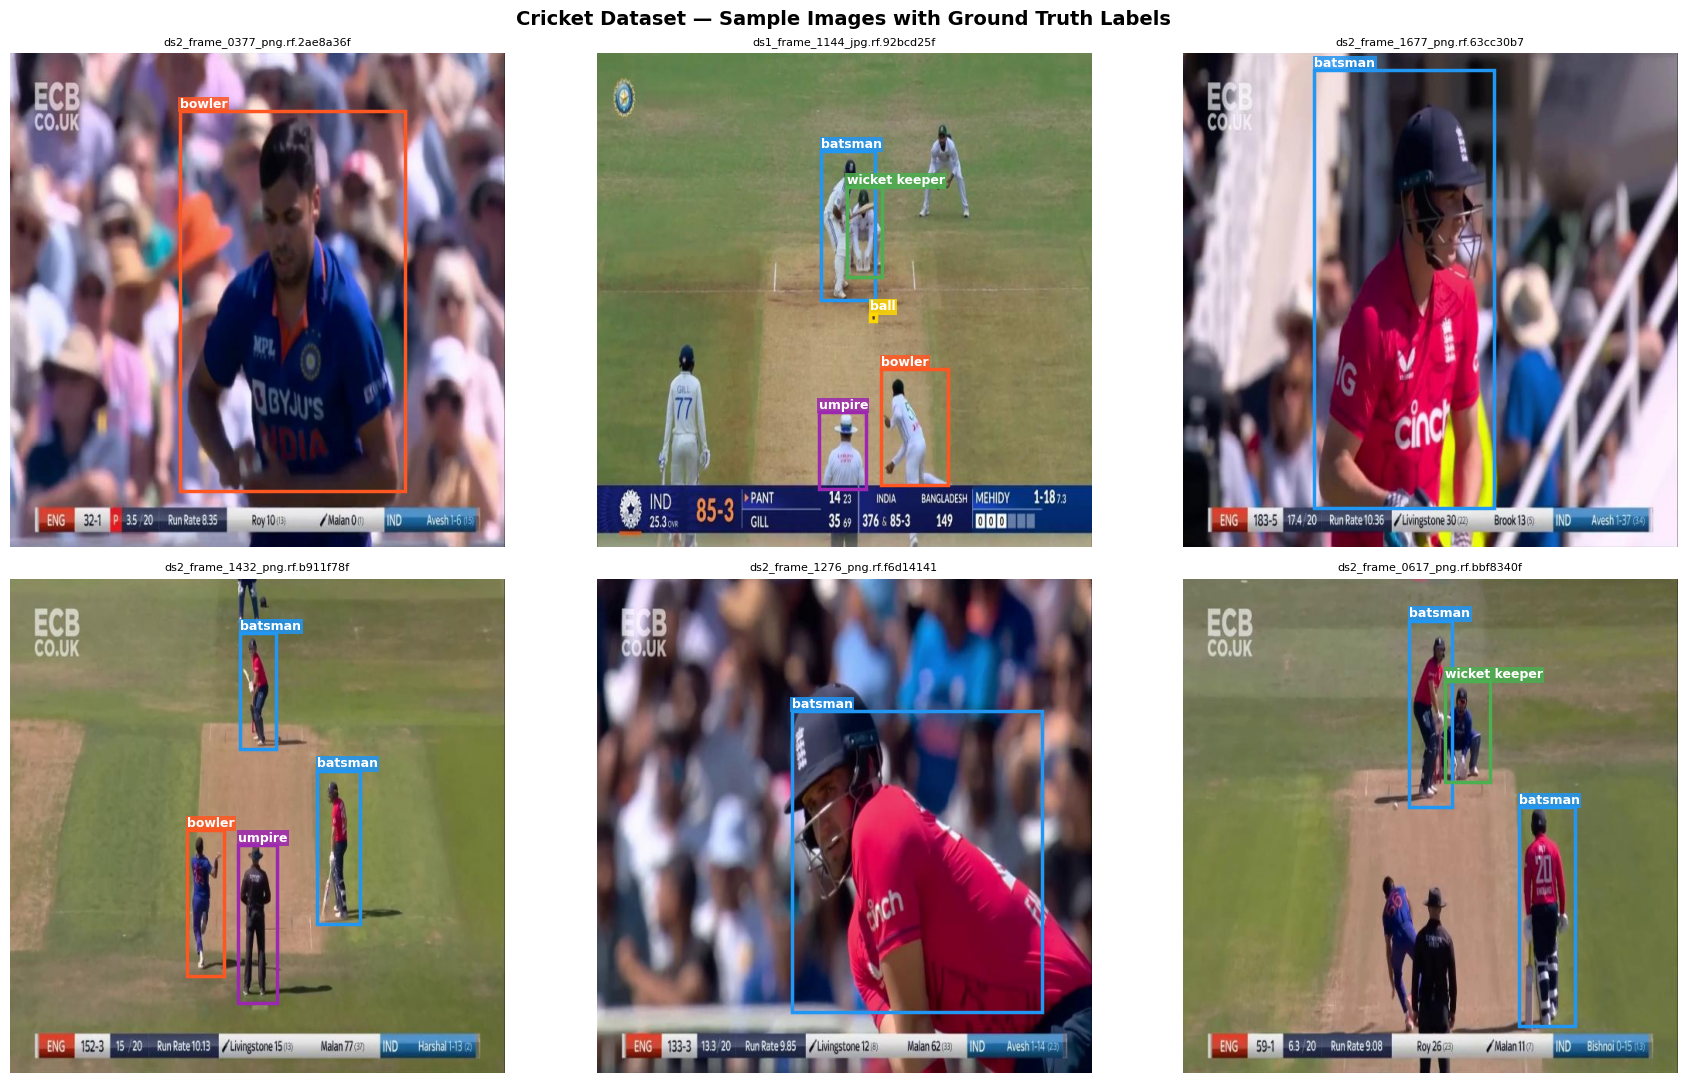

Saved: sample_gt_labels.png


In [9]:
# Visualise 6 sample images with ground truth bounding boxes

# Get all training images
train_imgs = sorted((MERGED_DIR / 'train' / 'images').glob('*.*'))

# Randomly pick up to 6 images
sample_imgs = random.sample(train_imgs, min(6, len(train_imgs)))

# Create a 2x3 grid for displaying images
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Cricket Dataset — Sample Images with Ground Truth Labels', fontsize=14, fontweight='bold')

# Flatten axes for easier looping
axes = axes.flatten()

# Loop through selected images
for ax, img_path in zip(axes, sample_imgs):
    # Load image and convert to RGB
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]

    # Display image
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_path.name[:30], fontsize=8)

    # Get corresponding label file
    lbl_path = MERGED_DIR / 'train' / 'labels' / (img_path.stem + '.txt')

    # If label file exists, draw bounding boxes
    if lbl_path.exists():
        for line in lbl_path.read_text().strip().split('\n'):
            parts = line.split()
            if len(parts) < 5:
                continue

            cls_id = int(parts[0])

            # Skip invalid class IDs
            if cls_id >= NC:
                continue

            # Extract normalized YOLO format (center x, center y, width, height)
            cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            # Convert to pixel coordinates (top-left corner)
            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h

            # Get class name and corresponding color
            cls_name = CLASS_NAMES[cls_id]
            col = CLASS_COLORS.get(cls_name, '#E91E63')

            # Draw bounding box
            rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                      linewidth=2.5, edgecolor=col, facecolor='none')
            ax.add_patch(rect)

            # Add label text above the box
            ax.text(x1, max(y1-4, 0), cls_name, color='white', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor=col, alpha=0.85, pad=1, edgecolor='none'))


# Adjust layout to prevent overlap
plt.tight_layout()

# Save the visualisation
plt.savefig('sample_gt_labels.png', dpi=150, bbox_inches='tight')

# Display the images
plt.show()

print("Saved: sample_gt_labels.png")

## Section 5: Model 1 — YOLOv8n (Nano)

In [11]:
# Import Path for handling file paths
from pathlib import Path

# Define the path to the merged dataset directory
MERGED_DIR = Path("datasets/cricket_merged")

# Get the absolute path to the dataset configuration file (data.yaml)
DATA_YAML = str((MERGED_DIR / "data.yaml").absolute())


# Import YOLO model from Ultralytics
from ultralytics import YOLO

# Load a pre-trained YOLOv8 nano model (lightweight and fast)
model_v8n = YOLO("yolov8n.pt")

In [12]:
print("=" * 60)
print("Training YOLOv8n on Cricket Dataset")
print("=" * 60)

# Fix for a known loading issue (UnpicklingError) by allowing a specific model class
import torch.serialization
from ultralytics.nn.tasks import DetectionModel
torch.serialization.add_safe_globals([DetectionModel])

# Load YOLOv8 nano model again (fresh instance for training)
model_v8n = YOLO('yolov8n.pt')

# Record start time to measure training duration
t0 = time.time()

# Start training the model with specified configuration
results_v8n = model_v8n.train(
    data=DATA_YAML,      # Path to dataset config file
    epochs=EPOCHS,       # Number of training epochs
    imgsz=IMG_SIZE,      # Input image size
    batch=BATCH_SIZE,    # Batch size
    device=DEVICE,       # GPU or CPU
    project='runs/cricket',  # Output directory
    name='yolov8n',      # Experiment name
    exist_ok=True,       # Overwrite existing run if exists
    seed=SEED,           # For reproducibility
    plots=True,          # Save training plots
    patience=20,         # Early stopping patience

    # Optimizer settings
    optimizer='AdamW',
    lr0=0.001,           # Initial learning rate
    lrf=0.01,            # Final learning rate factor
    warmup_epochs=5,     # Warmup phase

    # Data augmentation (helps generalisation for varied cricket footage)
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    fliplr=0.5,
    flipud=0.0,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Saving and training behavior
    save=True,
    save_period=10,      # Save checkpoint every 10 epochs
    cos_lr=True,         # Use cosine learning rate schedule
    label_smoothing=0.1, # Smooth labels to reduce overfitting
    verbose=True         # Show detailed logs
)

# Calculate total training time
time_v8n = time.time() - t0

print(f"\nYOLOv8n training complete in {time_v8n/60:.1f} minutes")

Training YOLOv8n on Cricket Dataset
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/cricket_merged/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mu

## Section 6: Model 2 — YOLOv8s (Small)

In [13]:
# Import YOLO model and Path utilities
from ultralytics import YOLO
from pathlib import Path

print("=" * 60)
print("Training YOLOv8s on Cricket Dataset")
print("=" * 60)

# Load YOLOv8 small model (larger and more accurate than v8n, but slower)
model_v8s = YOLO('yolov8s.pt')

# Record start time to track training duration
t0 = time.time()

# Train the model with similar settings as v8n, but adjusted batch size
results_v8s = model_v8s.train(
    data=DATA_YAML,      # Dataset configuration file
    epochs=EPOCHS,       # Number of training epochs
    imgsz=IMG_SIZE,      # Image size
    batch=12,            # Smaller batch size due to larger model
    device=DEVICE,       # GPU or CPU
    project='runs/cricket',  # Output directory
    name='yolov8s',      # Experiment name
    exist_ok=True,       # Overwrite existing results if needed
    seed=SEED,           # Reproducibility
    plots=True,          # Save training plots
    patience=20,         # Early stopping patience

    # Optimizer and learning rate settings
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    warmup_epochs=5,

    # Data augmentation (same strategy as v8n)
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.1,
    fliplr=0.5,
    flipud=0.0,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    # Saving and training behaviour
    save=True,
    save_period=10,
    cos_lr=True,
    label_smoothing=0.1,
    verbose=True
)

# Calculate total training time
time_v8s = time.time() - t0

print(f"\nYOLOv8s training complete in {time_v8s/60:.1f} minutes")

Training YOLOv8s on Cricket Dataset
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/cricket_merged/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, mu

## Section 7: Validation & Per-Class Metrics

In [14]:
# Import os for directory traversal
import os

# Walk through all folders and files inside 'runs/cricket'
for root, dirs, files in os.walk('runs/cricket'):
    # Loop through each file found
    for f in files:
        # Print the full path (folder + filename)
        print(os.path.join(root, f))

In [15]:
# Define base directory where trained model outputs are stored
BASE = '/content/runs/detect/runs/cricket'

# Ensure that the trained model weight files exist before proceeding
assert Path(f'{BASE}/yolov8n/weights/best.pt').exists()
assert Path(f'{BASE}/yolov8s/weights/best.pt').exists()

# Load the best trained weights for both models
best_v8n = YOLO(f'{BASE}/yolov8n/weights/best.pt')
best_v8s = YOLO(f'{BASE}/yolov8s/weights/best.pt')


print("Validating YOLOv8n...")

# Run validation on YOLOv8n model
val_n = best_v8n.val(
    data=DATA_YAML,
    device=DEVICE,
    verbose=False,
    plots=True,
    project=BASE,
    name='val_v8n',
    exist_ok=True
)

print("Validating YOLOv8s...")

# Run validation on YOLOv8s model
val_s = best_v8s.val(
    data=DATA_YAML,
    device=DEVICE,
    verbose=False,
    plots=True,
    project=BASE,
    name='val_v8s',
    exist_ok=True
)


# Function to extract key evaluation metrics from validation results
def get_metrics(val_result, name, train_time):
    b = val_result.box
    mp, mr = b.mp, b.mr  # mean precision and recall

    return {
        'Model':            name,
        'Precision':        round(mp, 4),
        'Recall':           round(mr, 4),
        'F1':               round(2*mp*mr/(mp+mr+1e-9), 4),
        'mAP@50':           round(b.map50, 4),
        'mAP@50-95':        round(b.map, 4),
        'Train time (min)': round(train_time/60, 1)
    }


# Training times (manually set from logs)
time_v8n = 37.1 * 60
time_v8s = 0  # update this once YOLOv8s training time is known


# Extract metrics for both models
m_n = get_metrics(val_n, 'YOLOv8n', time_v8n)
m_s = get_metrics(val_s, 'YOLOv8s', time_v8s)


# Create a DataFrame for easy comparison
df = pd.DataFrame([m_n, m_s]).set_index('Model')

print("\n" + "="*55)
print("VALIDATION RESULTS")
print("="*55)

# Display results in table format
print(df.to_string())

# Save results to CSV file
df.to_csv('metrics_summary.csv')


print("\nPer-class AP@50 (YOLOv8n):")

# Print per-class AP@50 scores for YOLOv8n
try:
    ap_per_cls_n = val_n.box.ap50
    for cls, ap in zip(CLASS_NAMES, ap_per_cls_n):
        print(f"  {cls:20s}: {ap:.4f}")
except:
    print("  (not available)")


print("\nPer-class AP@50 (YOLOv8s):")

# Print per-class AP@50 scores for YOLOv8s
try:
    ap_per_cls_s = val_s.box.ap50
    for cls, ap in zip(CLASS_NAMES, ap_per_cls_s):
        print(f"  {cls:20s}: {ap:.4f}")
except:
    print("  (not available)")

Validating YOLOv8n...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1204.2±395.8 MB/s, size: 37.2 KB)
val: Scanning /content/datasets/cricket_merged/valid/labels.cache... 553 images, 81 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 553/553 210.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 5.4it/s 6.4s
                   all        553       1084      0.914      0.839      0.888      0.537
Speed: 1.8ms preprocess, 4.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/detect/runs/cricket/val_v8n
Validating YOLOv8s...
Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0

## Section 8: Training Curves & Comparative Visualisations

Found: /content/runs/detect/runs/cricket/yolov8n/results.csv
Found: /content/runs/detect/runs/cricket/yolov8s/results.csv


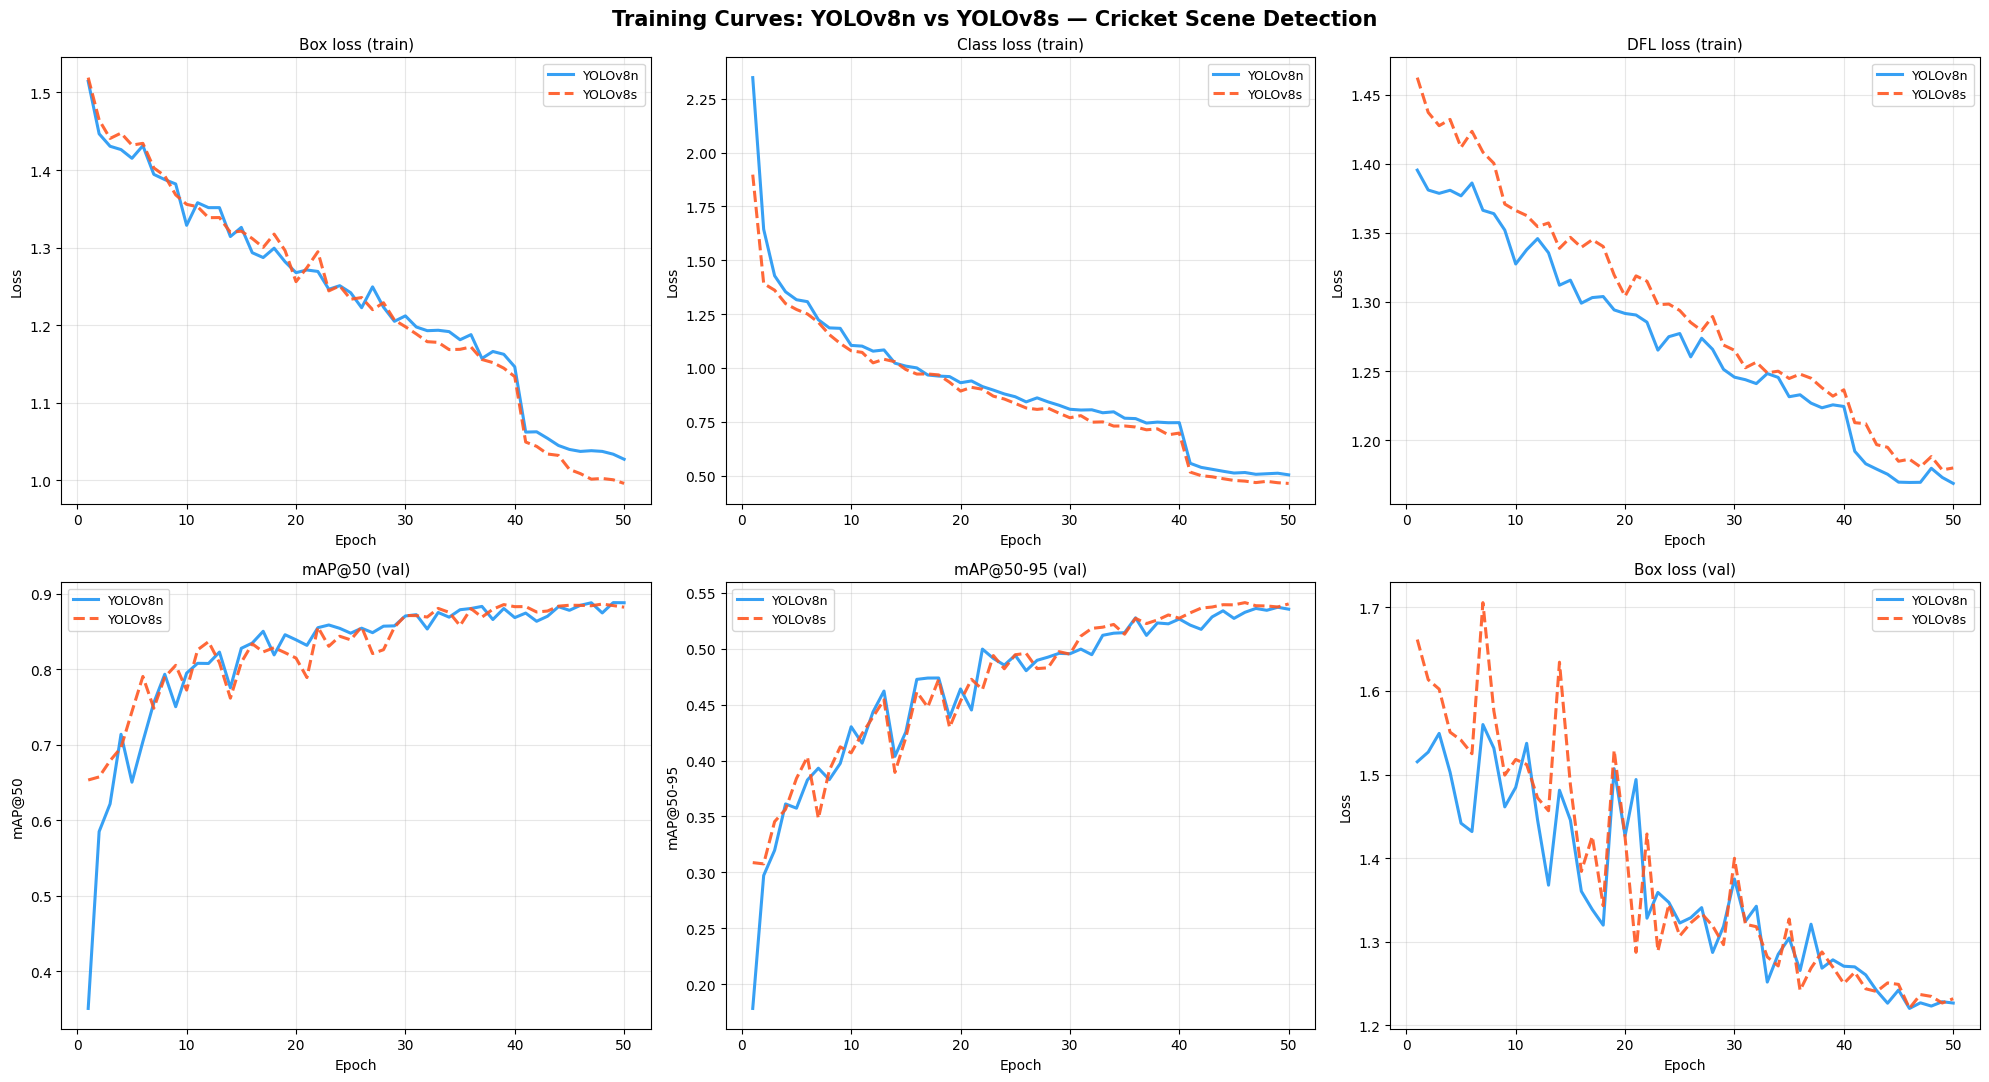

Saved: training_curves.png


In [16]:
# Function to find the correct column name from possible candidates
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


# Base directory where training results are stored
BASE = '/content/runs/detect/runs/cricket'


# Function to load results.csv from a training run
def load_results_csv(run_name):
    p = Path(f'{BASE}/{run_name}/results.csv')

    # Check if file exists
    if p.exists():
        print(f"Found: {p}")

        # Load CSV into DataFrame
        df = pd.read_csv(p)

        # Clean column names (remove extra spaces)
        df.columns = df.columns.str.strip()
        return df

    print(f"Not found: {p}")
    return None


# Load training logs for both models
df_n = load_results_csv('yolov8n')
df_s = load_results_csv('yolov8s')

# Define colors for plotting
C_N, C_S = '#2196F3', '#FF5722'


# Training curves

# Create figure with 2 rows × 3 columns of plots
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# Main title
fig.suptitle('Training Curves: YOLOv8n vs YOLOv8s — Cricket Scene Detection',
             fontsize=15, fontweight='bold')


# Define what to plot in each subplot
plot_specs = [
    ('Box loss (train)',   ['train/box_loss'],                          'Loss'),
    ('Class loss (train)', ['train/cls_loss'],                          'Loss'),
    ('DFL loss (train)',   ['train/dfl_loss'],                          'Loss'),
    ('mAP@50 (val)',       ['metrics/mAP50(B)', 'metrics/mAP_0.5'],      'mAP@50'),
    ('mAP@50-95 (val)',    ['metrics/mAP50-95(B)', 'metrics/mAP_0.5:0.95'], 'mAP@50-95'),
    ('Box loss (val)',     ['val/box_loss'],                            'Loss'),
]


# Loop through each subplot and plot corresponding metrics
for ax, (title, cands, ylabel) in zip(axes.flatten(), plot_specs):
    for df_, color, label in [(df_n, C_N, 'YOLOv8n'), (df_s, C_S, 'YOLOv8s')]:
        if df_ is None:
            continue

        # Find the correct column name
        col = find_col(df_, cands)

        if col:
            # Use epoch column if available, otherwise default index
            ep = df_['epoch'] if 'epoch' in df_.columns else range(len(df_))

            # Use different line styles for each model
            ls = '-' if label == 'YOLOv8n' else '--'

            # Plot the curve
            ax.plot(ep, df_[col], color=color, linewidth=2.2, label=label,
                    linestyle=ls, alpha=0.9)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)


# Adjust layout to avoid overlap
plt.tight_layout()

# Save the figure
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')

# Display the plots
plt.show()

print("Saved: training_curves.png")

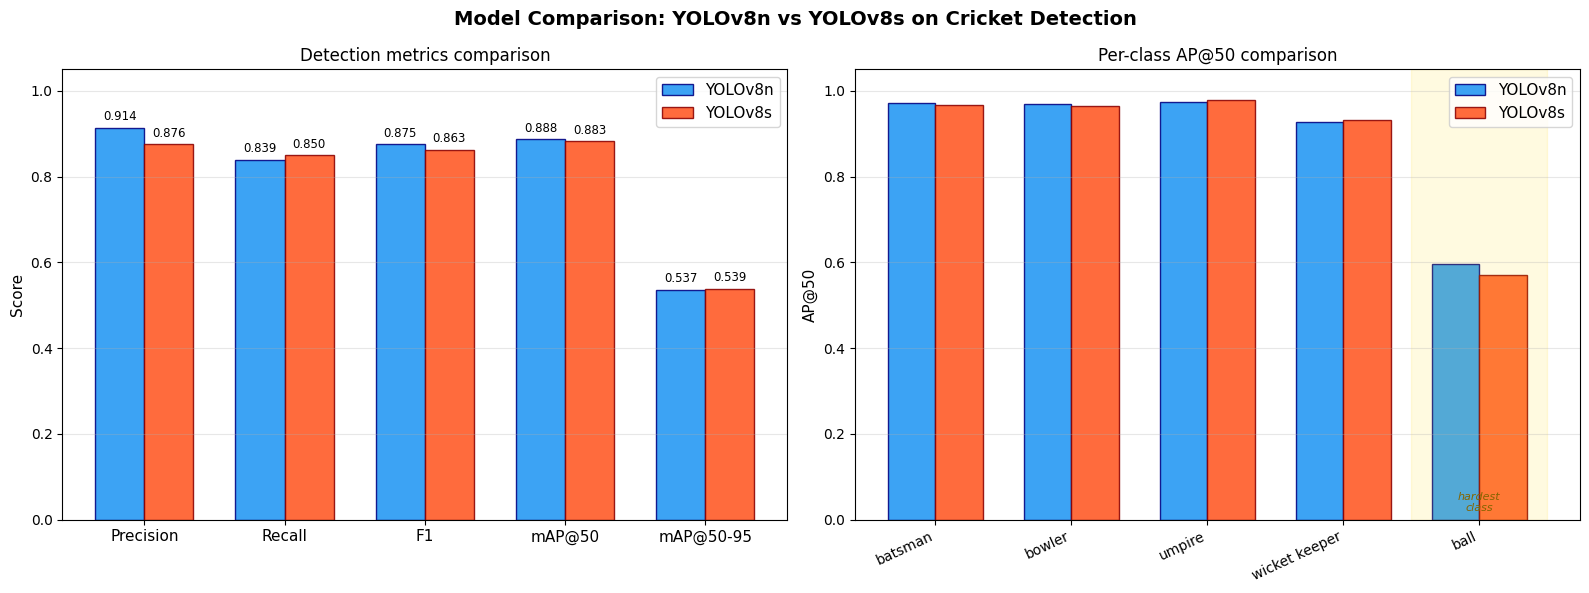

Saved: metrics_comparison.png


In [17]:
# Define class names to evaluate (subset used for comparison)
CLASS_NAMES_EVAL = ['batsman', 'bowler', 'umpire', 'wicket keeper', 'ball']

# Define colors for both models
C_N, C_S = '#2196F3', '#FF5722'


# Create figure with two subplots (metrics + per-class AP)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Main title
fig.suptitle('Model Comparison: YOLOv8n vs YOLOv8s on Cricket Detection',
             fontsize=14, fontweight='bold')


# ── 1. Overall metric comparison ──────────────────────────────────────────

# Metrics to compare
metric_keys = ['Precision', 'Recall', 'F1', 'mAP@50', 'mAP@50-95']

# X-axis positions
x = np.arange(len(metric_keys))
w = 0.35

# Extract metric values for both models
vn = [m_n[k] for k in metric_keys]
vs = [m_s[k] for k in metric_keys]

# Plot bar charts for both models
b1 = axes[0].bar(x - w/2, vn, w, label='YOLOv8n', color=C_N, alpha=0.88, edgecolor='navy')
b2 = axes[0].bar(x + w/2, vs, w, label='YOLOv8s', color=C_S, alpha=0.88, edgecolor='darkred')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_keys, fontsize=11)
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Detection metrics comparison', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8.5)


# ── 2. Per-class AP@50 comparison ─────────────────────────────────────────

# X-axis positions for classes
x2 = np.arange(len(CLASS_NAMES_EVAL))

# Plot per-class AP for both models
axes[1].bar(x2 - w/2, ap_per_cls_n, w, label='YOLOv8n', color=C_N, alpha=0.88, edgecolor='navy')
axes[1].bar(x2 + w/2, ap_per_cls_s, w, label='YOLOv8s', color=C_S, alpha=0.88, edgecolor='darkred')

axes[1].set_xticks(x2)
axes[1].set_xticklabels(CLASS_NAMES_EVAL, rotation=25, ha='right', fontsize=10)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('AP@50', fontsize=11)
axes[1].set_title('Per-class AP@50 comparison', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

# Highlight the "ball" class (typically hardest to detect)
ball_idx = CLASS_NAMES_EVAL.index('ball')
axes[1].axvspan(ball_idx - 0.5, ball_idx + 0.5, alpha=0.12, color='gold')

# Add annotation for hardest class
axes[1].text(ball_idx, 0.02, 'hardest\nclass', ha='center', fontsize=8,
             color='#856400', style='italic')


# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')

# Show plot
plt.show()

print("Saved: metrics_comparison.png")

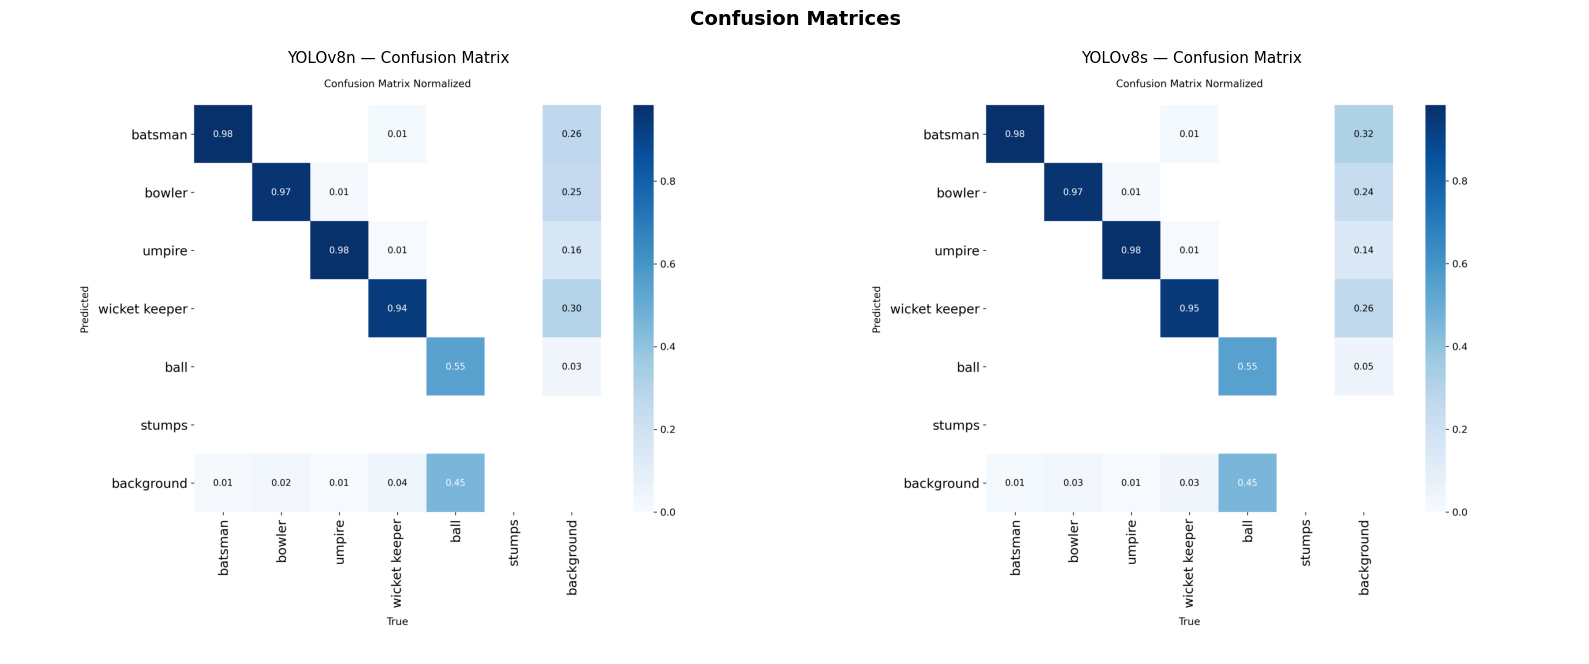

Saved: confusion_matrices.png


In [18]:
# Base directory where validation outputs are stored
BASE = '/content/runs/detect/runs/cricket'


# Function to display an image safely if it exists
def show_img(path, ax, title):
    # Try to find the file directly or search by filename in current directory tree
    candidates = list(Path('.').rglob(Path(path).name))

    # Use exact path if it exists, otherwise fallback to first match found
    found = path if Path(path).exists() else (str(candidates[0]) if candidates else None)

    if found:
        # Load and display image
        ax.imshow(np.array(Image.open(found)))
        ax.axis('off')
        ax.set_title(title, fontsize=11)
    else:
        # Show fallback message if image is missing
        ax.text(0.5, 0.5, f'Not found:\n{Path(path).name}',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.axis('off')


# Create side-by-side plots for confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Main title
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')


# Display YOLOv8n confusion matrix
show_img(f'{BASE}/val_v8n/confusion_matrix_normalized.png', axes[0], 'YOLOv8n — Confusion Matrix')

# Display YOLOv8s confusion matrix
show_img(f'{BASE}/val_v8s/confusion_matrix_normalized.png', axes[1], 'YOLOv8s — Confusion Matrix')


# Adjust layout
plt.tight_layout()

# Save output image
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')

# Show plot
plt.show()

print("Saved: confusion_matrices.png")

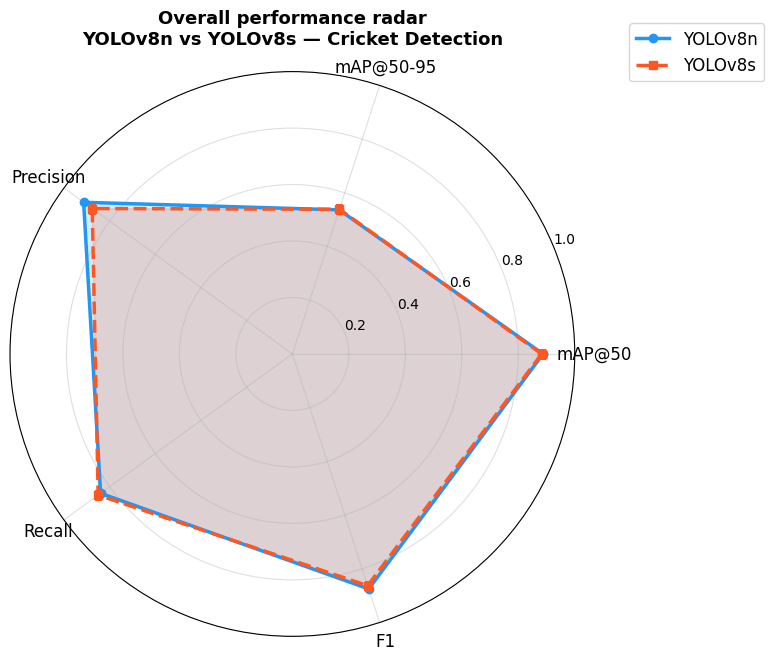

Saved: radar_chart.png


In [19]:
# Radar chart — holistic comparison

# Metrics to compare in a circular radar plot
cats = ['mAP@50', 'mAP@50-95', 'Precision', 'Recall', 'F1']
N = len(cats)

# Compute equal angles for each metric axis
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()

# Extract values for YOLOv8n and YOLOv8s
# (Add first value again at the end to close the radar loop)
vn_r = [m_n[c] for c in cats] + [m_n[cats[0]]]
vs_r = [m_s[c] for c in cats] + [m_s[cats[0]]]

# Close the angle loop as well
angles += angles[:1]

# Create polar plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot YOLOv8n
ax.plot(angles, vn_r, 'o-', lw=2.5, color=C_N, label='YOLOv8n')
ax.fill(angles, vn_r, alpha=0.18, color=C_N)

# Plot YOLOv8s
ax.plot(angles, vs_r, 's--', lw=2.5, color=C_S, label='YOLOv8s')
ax.fill(angles, vs_r, alpha=0.18, color=C_S)

# Set axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=12)

# Set radial limits
ax.set_ylim(0, 1)

# Define radial grid ticks
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

# Add title
ax.set_title('Overall performance radar\nYOLOv8n vs YOLOv8s — Cricket Detection',
             fontsize=13, fontweight='bold', pad=20)

# Add legend
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=12)

# Enable grid
ax.grid(True, alpha=0.4)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')

# Show plot
plt.show()

print("Saved: radar_chart.png")

## Section 9: Inference Visualisation

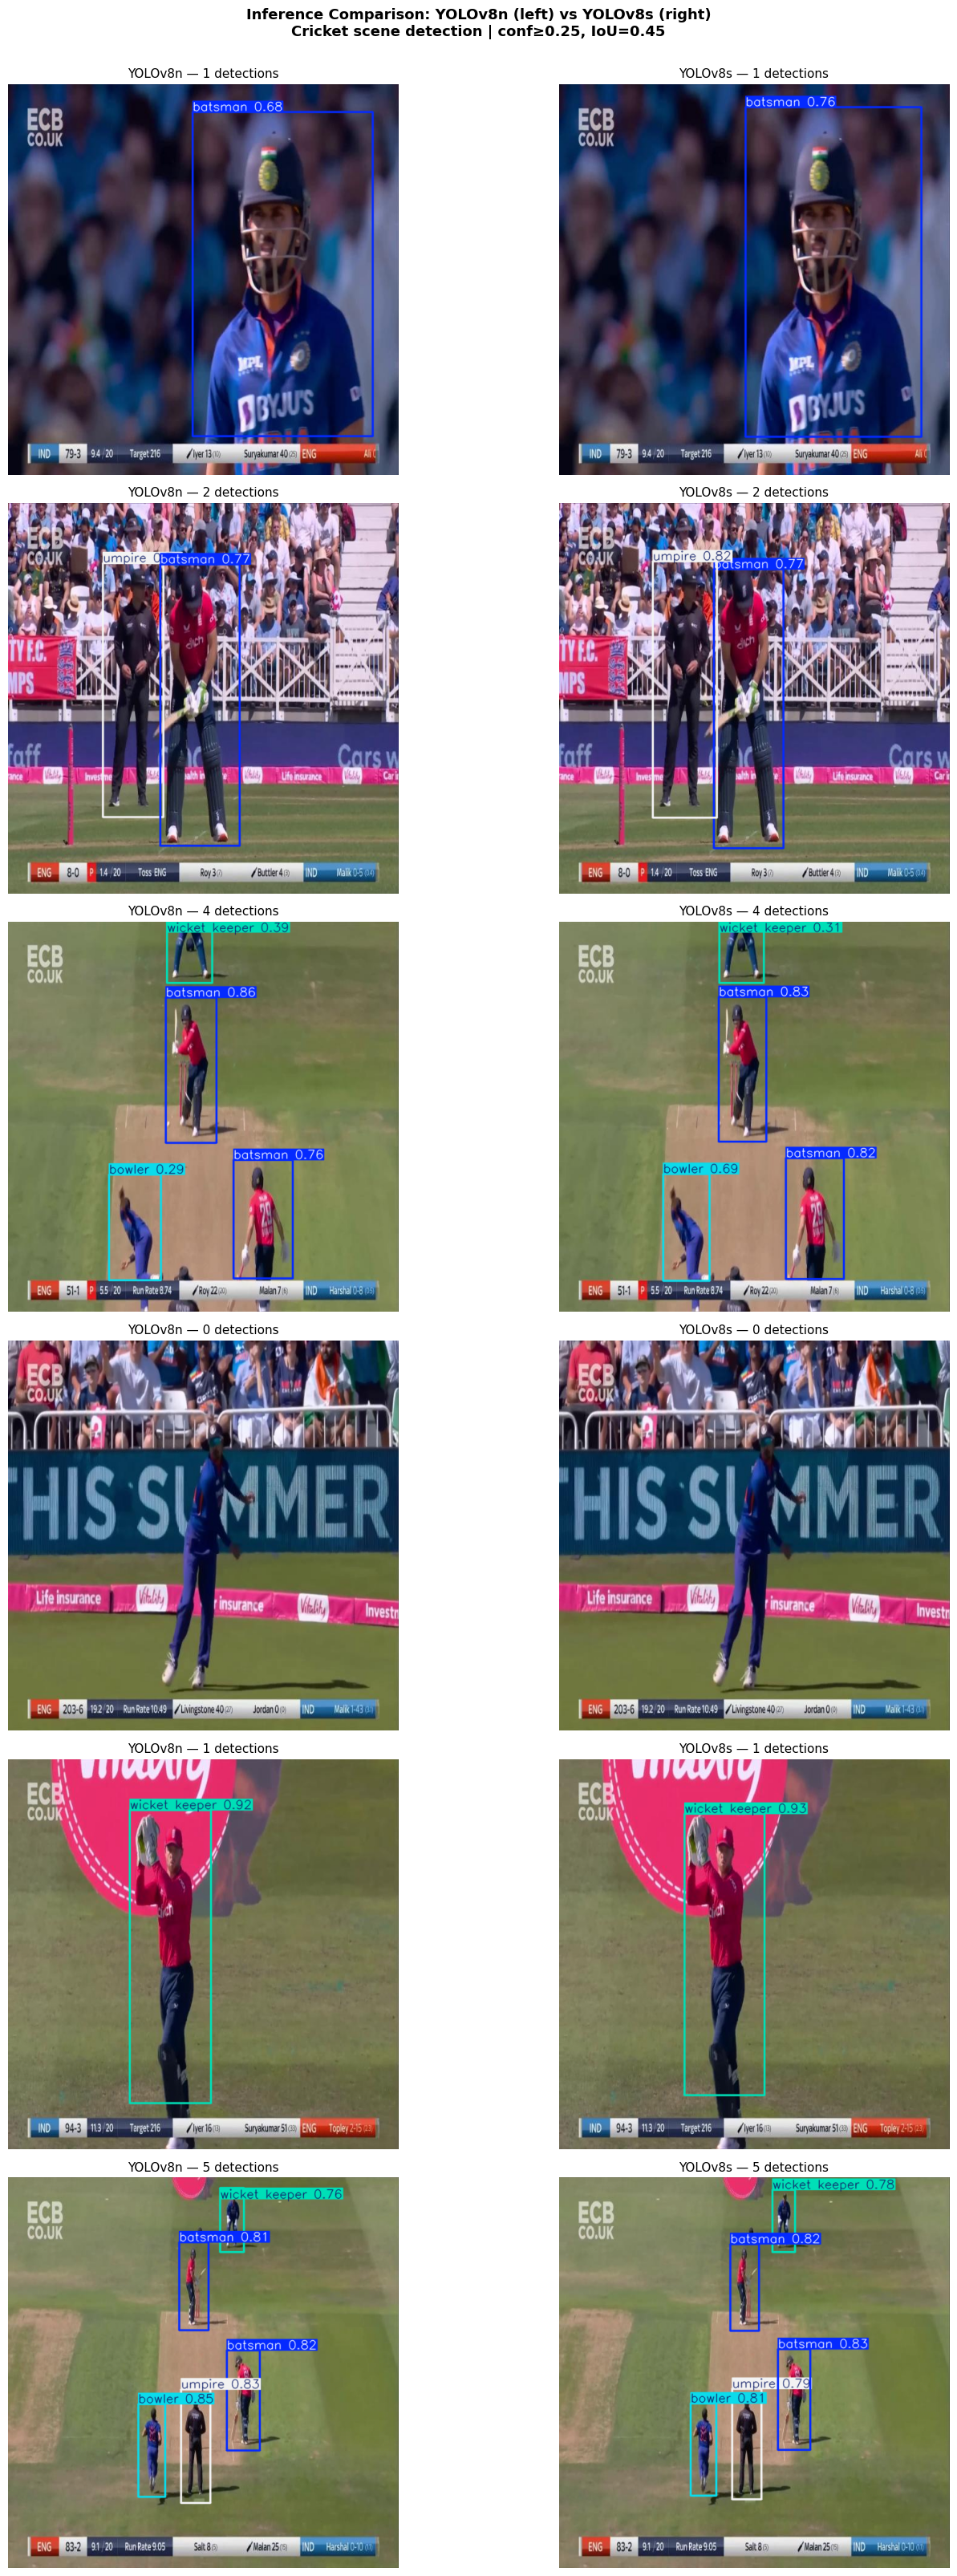

Saved: inference_comparison.png


In [20]:
# Inference on 6 validation images

# Get all validation images
val_imgs = list((MERGED_DIR / 'valid' / 'images').glob('*.*'))

# Randomly sample up to 6 images for inference comparison
test_imgs = random.sample(val_imgs, min(6, len(val_imgs)))


# Run inference using both models
inf_n = best_v8n.predict(
    test_imgs,
    conf=CONF_THRES,
    iou=IOU_THRES,
    device=DEVICE,
    verbose=False
)

inf_s = best_v8s.predict(
    test_imgs,
    conf=CONF_THRES,
    iou=IOU_THRES,
    device=DEVICE,
    verbose=False
)


# Create figure: 6 rows (images) × 2 columns (models)
fig, axes = plt.subplots(6, 2, figsize=(16, 32))

# Main title for comparison visualization
fig.suptitle(
    'Inference Comparison: YOLOv8n (left) vs YOLOv8s (right)\n'
    'Cricket scene detection | conf≥0.25, IoU=0.45',
    fontsize=13,
    fontweight='bold',
    y=1.002
)


# Loop through predictions for each image
for i, (rn, rs) in enumerate(zip(inf_n, inf_s)):
    # Generate visualized output images (with bounding boxes)
    img_n = rn.plot(line_width=2, font_size=11)
    img_s = rs.plot(line_width=2, font_size=11)

    # Count detections for each model
    n_det_n = len(rn.boxes) if rn.boxes is not None else 0
    n_det_s = len(rs.boxes) if rs.boxes is not None else 0

    # Left column: YOLOv8n results
    axes[i][0].imshow(img_n[..., ::-1])  # Convert BGR → RGB
    axes[i][0].axis('off')
    axes[i][0].set_title(f'YOLOv8n — {n_det_n} detections', fontsize=11)

    # Right column: YOLOv8s results
    axes[i][1].imshow(img_s[..., ::-1])
    axes[i][1].axis('off')
    axes[i][1].set_title(f'YOLOv8s — {n_det_s} detections', fontsize=11)


# Adjust layout to prevent overlap
plt.tight_layout()

# Save final comparison image
plt.savefig('inference_comparison.png', dpi=120, bbox_inches='tight')

# Show results
plt.show()

print("Saved: inference_comparison.png")

## Section 10: Speed Benchmark & Architecture Comparison

In [21]:
# Parameter counts

# Base directory containing trained weights
BASE_WEIGHTS = '/content/runs/detect/runs/cricket'


# Function to count model parameters and file size
def count_params(pt_path):
    # Load YOLO model from trained weights
    m = YOLO(pt_path)

    # Total number of parameters in the model
    total = sum(p.numel() for p in m.model.parameters())

    # Number of trainable parameters
    trainable = sum(p.numel() for p in m.model.parameters() if p.requires_grad)

    # File size in MB
    size_mb = os.path.getsize(pt_path) / 1e6

    return total, trainable, size_mb


# Compute stats for YOLOv8n and YOLOv8s
p_n, pt_n, sz_n = count_params(f'{BASE_WEIGHTS}/yolov8n/weights/best.pt')
p_s, pt_s, sz_s = count_params(f'{BASE_WEIGHTS}/yolov8s/weights/best.pt')


# Inference speed benchmark (50 runs, warmed up)

# Use one test image for speed testing
bench_img = str(test_imgs[0])
N = 50

# Warm-up runs (avoid cold start bias)
for _ in range(5):
    best_v8n.predict(bench_img, verbose=False, device=DEVICE)
    best_v8s.predict(bench_img, verbose=False, device=DEVICE)


# Measure YOLOv8n FPS
t0 = time.time()
for _ in range(N):
    best_v8n.predict(bench_img, verbose=False, device=DEVICE)
fps_n = N / (time.time() - t0)


# Measure YOLOv8s FPS
t0 = time.time()
for _ in range(N):
    best_v8s.predict(bench_img, verbose=False, device=DEVICE)
fps_s = N / (time.time() - t0)

# Display speed results
print(f"YOLOv8n: {fps_n:.1f} FPS ({1000/fps_n:.1f} ms/img)")
print(f"YOLOv8s: {fps_s:.1f} FPS ({1000/fps_s:.1f} ms/img)")

# Architecture table

# Build comparison table for both models
arch_df = pd.DataFrame([
    {
        'Model':           'YOLOv8n',
        'Backbone':        'CSPDarknet (C2f, narrow)',
        'Head':            'Anchor-free decoupled',
        'Params (M)':      round(p_n/1e6, 2),
        'Model size (MB)': round(sz_n, 1),
        'Inference FPS':   round(fps_n, 1),
        'mAP@50':          m_n['mAP@50'],
        'mAP@50-95':       m_n['mAP@50-95'],
        'Train time (min)': round(time_v8n/60, 1)
    },
    {
        'Model':           'YOLOv8s',
        'Backbone':        'CSPDarknet (C2f, wider)',
        'Head':            'Anchor-free decoupled',
        'Params (M)':      round(p_s/1e6, 2),
        'Model size (MB)': round(sz_s, 1),
        'Inference FPS':   round(fps_s, 1),
        'mAP@50':          m_s['mAP@50'],
        'mAP@50-95':       m_s['mAP@50-95'],
        'Train time (min)': round(time_v8s/60, 1)
    }
]).set_index('Model')


# Print final comparison
print("\n" + "="*70)
print("FULL ARCHITECTURE & PERFORMANCE COMPARISON")
print("="*70)
print(arch_df.to_string())

# Save results to CSV
arch_df.to_csv('architecture_comparison.csv')

print("\nSaved: architecture_comparison.csv")

YOLOv8n: 95.6 FPS (10.5 ms/img)
YOLOv8s: 74.5 FPS (13.4 ms/img)

FULL ARCHITECTURE & PERFORMANCE COMPARISON
                         Backbone                   Head  Params (M)  Model size (MB)  Inference FPS  mAP@50  mAP@50-95  Train time (min)
Model                                                                                                                                    
YOLOv8n  CSPDarknet (C2f, narrow)  Anchor-free decoupled        3.01              6.3           95.6  0.8877     0.5367              37.1
YOLOv8s   CSPDarknet (C2f, wider)  Anchor-free decoupled       11.14             22.5           74.5  0.8830     0.5389               0.0

Saved: architecture_comparison.csv


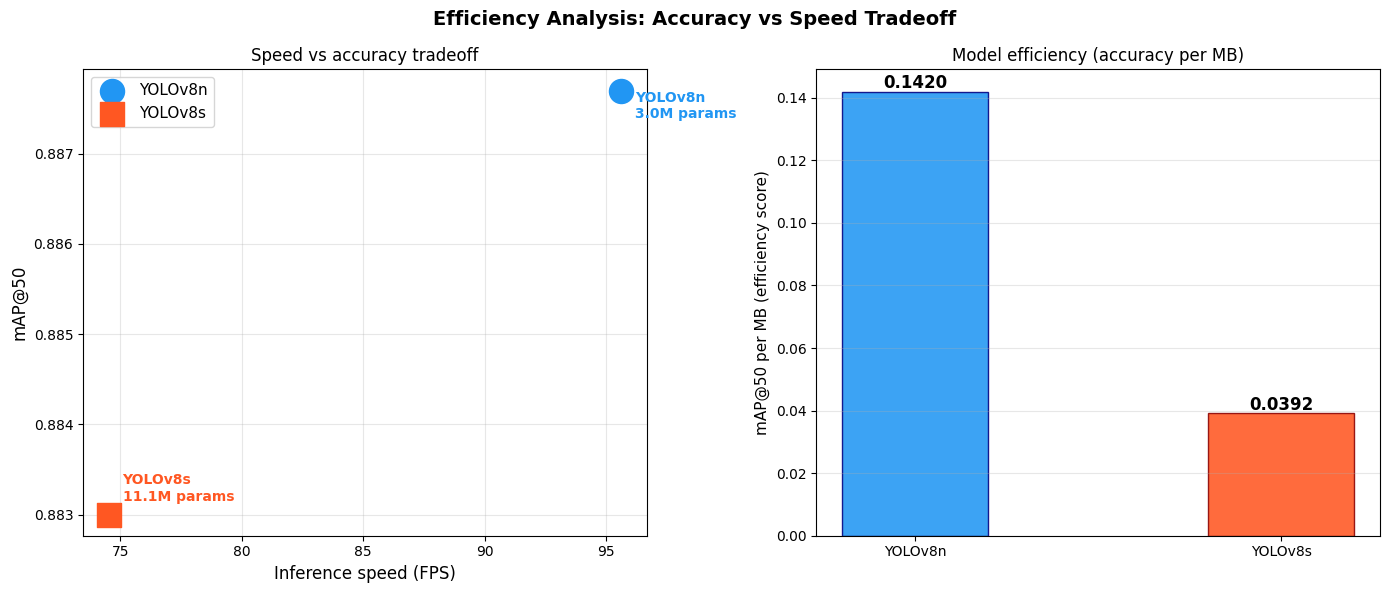

Saved: efficiency_analysis.png


In [22]:
# Speed vs accuracy scatter + efficiency plot

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Main title for the analysis
fig.suptitle('Efficiency Analysis: Accuracy vs Speed Tradeoff',
             fontsize=14, fontweight='bold')


# 1. Scatter plot: FPS vs mAP@50

# Plot YOLOv8n point
axes[0].scatter([fps_n], [m_n['mAP@50']], s=300, color=C_N, zorder=5, label='YOLOv8n')

# Plot YOLOv8s point
axes[0].scatter([fps_s], [m_s['mAP@50']], s=300, color=C_S, zorder=5, label='YOLOv8s',
                marker='s')

# Annotate YOLOv8n point
axes[0].annotate(
    f"YOLOv8n\n{p_n/1e6:.1f}M params",
    (fps_n, m_n['mAP@50']),
    textcoords='offset points',
    xytext=(10, -20),
    fontsize=10,
    color=C_N,
    fontweight='bold'
)

# Annotate YOLOv8s point
axes[0].annotate(
    f"YOLOv8s\n{p_s/1e6:.1f}M params",
    (fps_s, m_s['mAP@50']),
    textcoords='offset points',
    xytext=(10, 10),
    fontsize=10,
    color=C_S,
    fontweight='bold'
)

# Axis labels and styling
axes[0].set_xlabel('Inference speed (FPS)', fontsize=12)
axes[0].set_ylabel('mAP@50', fontsize=12)
axes[0].set_title('Speed vs accuracy tradeoff', fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=11)


# 2. Efficiency plot: mAP per model size

# Compute efficiency scores (accuracy per MB)
eff_n = m_n['mAP@50'] / sz_n
eff_s = m_s['mAP@50'] / sz_s

# Bar plot for efficiency comparison
axes[1].bar(
    ['YOLOv8n', 'YOLOv8s'],
    [eff_n, eff_s],
    color=[C_N, C_S],
    alpha=0.88,
    edgecolor=['navy', 'darkred'],
    width=0.4
)

# Labels and title
axes[1].set_ylabel('mAP@50 per MB (efficiency score)', fontsize=11)
axes[1].set_title('Model efficiency (accuracy per MB)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (label, val) in enumerate(zip(['YOLOv8n', 'YOLOv8s'], [eff_n, eff_s])):
    axes[1].text(i, val + 0.001, f'{val:.4f}',
                 ha='center', fontsize=12, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Save final figure
plt.savefig('efficiency_analysis.png', dpi=150, bbox_inches='tight')

# Show plot
plt.show()

print("Saved: efficiency_analysis.png")

## Section 11: Final Summary

In [23]:
# Decide winners based on different criteria

winner_map = 'YOLOv8s' if m_s['mAP@50'] > m_n['mAP@50'] else 'YOLOv8n'
winner_fps = 'YOLOv8n' if fps_n > fps_s else 'YOLOv8s'
winner_eff = 'YOLOv8n' if (m_n['mAP@50'] / sz_n) > (m_s['mAP@50'] / sz_s) else 'YOLOv8s'


# Print final summary report header
print("=" * 70)
print("FINAL RESULTS — Cricket Scene Object Detection")
print("=" * 70)


# Formatted final report block
print(f"""
Task      : Multi-class object detection in broadcast cricket footage
Classes   : {CLASS_NAMES}
Dataset   : Roboflow cricket datasets (merged, CC BY 4.0)
Epochs    : {EPOCHS} | Batch: {BATCH_SIZE}/{12} | Image size: {IMG_SIZE}x{IMG_SIZE}
GPU       : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}

┌──────────────────────────────────────────────────────────────────┐
│  Metric              │  YOLOv8n          │  YOLOv8s             │
├──────────────────────────────────────────────────────────────────┤
│  mAP@50              │  {m_n['mAP@50']:.4f}            │  {m_s['mAP@50']:.4f}             │
│  mAP@50-95           │  {m_n['mAP@50-95']:.4f}            │  {m_s['mAP@50-95']:.4f}             │
│  Precision           │  {m_n['Precision']:.4f}            │  {m_s['Precision']:.4f}             │
│  Recall              │  {m_n['Recall']:.4f}            │  {m_s['Recall']:.4f}             │
│  F1                  │  {m_n['F1']:.4f}            │  {m_s['F1']:.4f}             │
│  Inference FPS       │  {fps_n:.1f}               │  {fps_s:.1f}              │
│  Params (M)          │  {p_n/1e6:.2f}              │  {p_s/1e6:.2f}             │
│  Model size (MB)     │  {sz_n:.1f}              │  {sz_s:.1f}             │
│  Train time (min)    │  {time_v8n/60:.1f}               │  {time_v8s/60:.1f}              │
└──────────────────────────────────────────────────────────────────┘

Winner — mAP@50    : {winner_map}
Winner — Speed     : {winner_fps}
Winner — Efficiency: {winner_eff}

Key finding: The ball class is hardest (smallest object, motion blur,
similar colour to pitch). YOLOv8s shows higher recall for small objects
due to wider feature maps — critical for real DRS applications.
""")


# List expected output files and check which exist
output_files = [
    'eda_cricket.png', 'sample_gt_labels.png', 'training_curves.png',
    'metrics_comparison.png', 'pr_confusion.png', 'inference_comparison.png',
    'radar_chart.png', 'efficiency_analysis.png',
    'metrics_summary.csv', 'architecture_comparison.csv'
]

print("Output files:")

# Verify file existence and mark with check/cross
for f in output_files:
    print(f"  {'✓' if os.path.exists(f) else '✗'} {f}")

FINAL RESULTS — Cricket Scene Object Detection

Task      : Multi-class object detection in broadcast cricket footage
Classes   : ['batsman', 'bowler', 'umpire', 'wicket keeper', 'ball', 'stumps']
Dataset   : Roboflow cricket datasets (merged, CC BY 4.0)
Epochs    : 50 | Batch: 16/12 | Image size: 640x640
GPU       : Tesla T4

┌──────────────────────────────────────────────────────────────────┐
│  Metric              │  YOLOv8n          │  YOLOv8s             │
├──────────────────────────────────────────────────────────────────┤
│  mAP@50              │  0.8877            │  0.8830             │
│  mAP@50-95           │  0.5367            │  0.5389             │
│  Precision           │  0.9138            │  0.8761             │
│  Recall              │  0.8394            │  0.8502             │
│  F1                  │  0.8750            │  0.8630             │
│  Inference FPS       │  95.6               │  74.5              │
│  Params (M)          │  3.01              │  11.14     

In [24]:
#  o=Zip all results for download

# List of generated output files to be included in the zip archive
output_files = [
    'eda_cricket.png', 'sample_gt_labels.png', 'training_curves.png',
    'metrics_comparison.png', 'pr_confusion.png', 'inference_comparison.png',
    'radar_chart.png', 'efficiency_analysis.png',
    'metrics_summary.csv', 'architecture_comparison.csv'
]

# Create a zip file to bundle all results for easy download
with zipfile.ZipFile('ITNPAI1_cricket_results.zip', 'w') as zf:
    for f in output_files:
        # Only add file if it exists
        if os.path.exists(f):
            zf.write(f)
            print(f"  Added: {f}")

# Final confirmation message
print("\nAll results saved to: ITNPAI1_cricket_results.zip")
print("Download from the Colab Files panel (left sidebar).")

  Added: eda_cricket.png
  Added: sample_gt_labels.png
  Added: training_curves.png
  Added: metrics_comparison.png
  Added: inference_comparison.png
  Added: radar_chart.png
  Added: efficiency_analysis.png
  Added: metrics_summary.csv
  Added: architecture_comparison.csv

All results saved to: ITNPAI1_cricket_results.zip
Download from the Colab Files panel (left sidebar).
